PHASE 4 FINAL PROJECT

1.TITLE

A MOVIE RECOMMENDER SYSTEM USING THE MOVIELENS LATEST SMALL DATASET



2.INTRODUCTION

Recommendation systems are machine learning tools that help users discover relevant items from large collection of content by analyzing preferences and past interactions. They play an important role in reducing information overload and improving user experience by providing personalized suggestions.These systems are widely used in streaming services,e-commerce platforms and social media applications to recommend movies,music,products and other content that users are likely to find interesting. Personalized recommendations help increase user engagement,satisfaction and retention.

There are three main types of recommendation systems: content-based filtering,collaborative filtering and hybrid systems.Content-based filtering recommends items similar to those a user has previously liked, while collaborative filtering recommends items based on the preferences of similar users.Hybrid systems on the other hand combines both approaches to improve recommendation quality and accuracy.

In this project, i intend to develop a hybrid movie recommendation system using the MovieLens Latest Small dataset. The system leverages both movie attributes and user rating patterns to generate personalized recommendations,demonstrating how machine learning can be used to enhance content discovery and user experience.



2. DATA UNDERSTANDING

In [18]:
!pip install surprise


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:

#Import libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader , SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [20]:
#load the dataset

movies = pd.read_csv('ml-latest-small/ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ml-latest-small/ratings.csv')
tags = pd.read_csv('ml-latest-small/ml-latest-small/tags.csv')

In [21]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [22]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [23]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [24]:
movies.shape

(9742, 3)

In [25]:
ratings.shape

(100836, 4)

In [26]:
tags.shape

(3683, 4)

In [27]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [28]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [29]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


In [30]:
#merge the dataset
movies = movies.merge(ratings,on='movieId')

DATA PREPROCESSING AND EDA

In [31]:
#find missing values
movies.isnull().sum()

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [32]:
#find duplicates
movies.duplicated().sum()

np.int64(0)

In [33]:
movies.columns

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp'], dtype='str')

In [34]:
movies['movieId'].nunique()

9724

In [35]:
len(movies)

100836

In [36]:
#Genre distribution
genres_counts = movies['genres'].str.split('|').explode().value_counts()
print(genres_counts)

genres
Drama                 41928
Comedy                39053
Action                30635
Thriller              26452
Adventure             24161
Romance               18124
Sci-Fi                17243
Crime                 16681
Fantasy               11834
Children               9208
Mystery                7674
Horror                 7291
Animation              6988
War                    4859
IMAX                   4145
Musical                4138
Western                1930
Documentary            1219
Film-Noir               870
(no genres listed)       47
Name: count, dtype: int64


In [37]:
movies.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [38]:
import matplotlib.pyplot as plt
movies_genre = movies['genres'].str.split('|').explode()

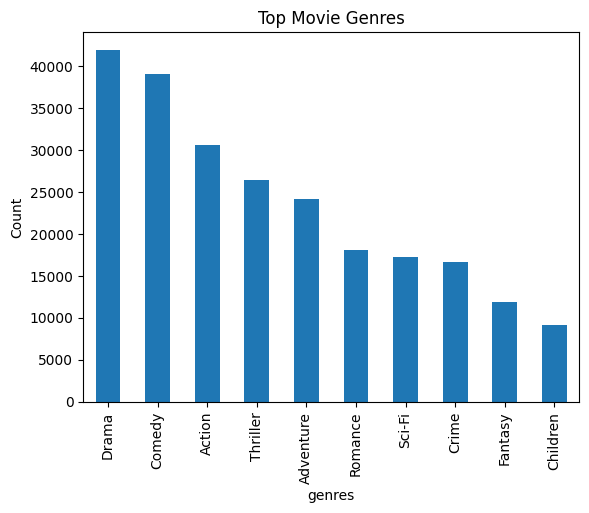

In [48]:
#Visualize genres
import matplotlib.pyplot as plt
movies_genres = movies['genres'].str.split('|').explode()
movies_genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Movie Genres")
plt.xlabel("genres")
plt.ylabel("Count")
plt.show()

In [ ]:
#Most frequent movies
movies['title'].value_counts().head(10)

title
Emma (1996)                               2
Saturn 3 (1980)                           2
Confessions of a Dangerous Mind (2002)    2
Eros (2004)                               2
War of the Worlds (2005)                  2
Toy Story (1995)                          1
Jumanji (1995)                            1
Grumpier Old Men (1995)                   1
Waiting to Exhale (1995)                  1
Father of the Bride Part II (1995)        1
Name: count, dtype: int64

In [50]:
#Top 10 most recommended movie
movies.groupby('title') \
      .count() \
      .sort_values(by='movieId', ascending=False) \
      .head(10)

,movieId,genres,userId,rating,timestamp,content
title,,,,,,
Forrest Gump (1994),329,329,329,329,329,329
"Shawshank Redemption, The (1994)",317,317,317,317,317,317
Pulp Fiction (1994),307,307,307,307,307,307
"Silence of the Lambs, The (1991)",279,279,279,279,279,279
"Matrix, The (1999)",278,278,278,278,278,278
Star Wars: Episode IV - A New Hope (1977),251,251,251,251,251,251
Jurassic Park (1993),238,238,238,238,238,238
Braveheart (1995),237,237,237,237,237,237
Terminator 2: Judgment Day (1991),224,224,224,224,224,224


In [51]:
#Create content features
movies['content'] = (movies['title'].astype(str) + '' + 
movies['genres'].astype(str))

TF-IDF VECTORIZATION

In [ ]:
!pip install scikit-learn


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english')
tfidf_metrics = tfidf.fit_transform(movies['content'])

In [57]:
movies_unique = movies[['movieId', 'title', 'genres']].drop_duplicates(subset='movieId').reset_index(drop=True)
movies_unique['genres_clean'] = movies_unique['genres'].str.replace('|', ' ', regex=False)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_unique['genres_clean'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies_unique.index, index=movies_unique['title']).drop_duplicates()

In [59]:
def recommend(title, cosine_sim=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movies_unique['title'].iloc[movie_indices]

In [63]:
print(movies_unique.shape)
print(cosine_sim.shape)

(9724, 4)
(9724, 9724)


In [61]:
#Creating a recommendation function
def recommend(title, cosine_sim=cosine_sim):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]  

    movies_indices = [i[0] for i in sim_scores] 

    return movies['title'].iloc[movies_indices]

In [65]:
recommend("Toy Story (1995)")

1705                                          Babe (1995)
2353                                    Pocahontas (1995)
2805                                      Bio-Dome (1996)
2996       Things to Do in Denver When You're Dead (1995)
3563                                    Braveheart (1995)
6177                             Dolores Claiborne (1995)
6469                                   French Kiss (1995)
6931            Star Wars: Episode IV - A New Hope (1977)
7742    Léon: The Professional (a.k.a. The Professiona...
8201                                     Quiz Show (1994)
Name: title, dtype: str

The recommendation function returns a list of movies that are most similar to the input movie. the similarity is computed using cosine similarity on TF-IDF transformed movie metadata. The higer the similarity score, the more related the movies are in terms of genre and content features.

COLLABORATIVE FILTERING